# `AA Workshop 9` — Coding Challenge

Complete the tasks below to practice implementing classification modeling from `W9_Trees_Ensembles.ipynb`.

Guidelines:
- Work in order. Run each cell after editing with Shift+Enter.
- Keep answers short; focus on making things work.
- If a step fails, read the error and fix it.

By the end you will have exercised:
- implementing a decision tree
- determining the optimal alpha to control overfitting
- plotting a tree

## Task 1 - Training a Generalizable Tree Classifier for Detecting Forged Banknotes

You are already familiar with the dataset containing data extracted from images that were taken from genuine and forged banknote-like specimens (raw data available as `BankNote_Authentication.csv` in the `data` directory; more information [here](https://archive.ics.uci.edu/dataset/267/banknote+authentication)). Let's train a decision tree classifier, and pay particular attention to the problem of overfitting by implementing a grid search over the identified effective alphas to determine where predictive performance is maximized. Do the following:
- load and inspect the data, then define your feature vector X (we only want to consider the features `variance` and `entropy`) and target Y (the `class`)
- perform a train-holdout-test split
- train a decision tree without a limit on the maximum depth, then compute the cost complexity pruning path
- calculate and plot the training vs. holdout accuracy for each effective alpha
- finally, plot the best performing tree and calculate the accuracy on the test set

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/BankNote_Authentication.csv')
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [2]:
X = df[['variance', 'entropy']].values
Y = df['class'].values

print(X.shape)

(1372, 2)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_, Y_train, Y_ = train_test_split(X, Y, test_size=0.5, random_state=42, stratify=Y)
X_val, X_test, Y_val, Y_test = train_test_split(X_, Y_, test_size=0.5, random_state=42, stratify=Y_)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

tree_classifier = DecisionTreeClassifier(max_depth=None, criterion='gini', min_samples_leaf=1, random_state=42)
tree_classifier.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [5]:
print(tree_classifier.get_depth())

12


In [6]:
path = tree_classifier.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities


val_accuracies = {}
train_accuracies = {}
# for ccp_alpha in ccp_alphas:
for ccp_alpha in np.linspace(ccp_alphas[0], ccp_alphas[-1], num=1000):
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, Y_train)
    val_accuracies[ccp_alpha] = clf.score(X_val, Y_val)
    train_accuracies[ccp_alpha] = clf.score(X_train, Y_train)

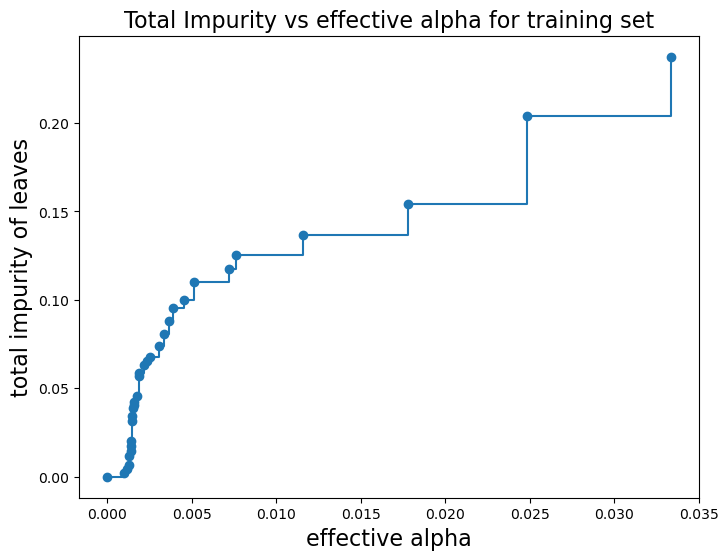

In [7]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")  # we remove the last alpha as this corresponds to a tree with only the root node
ax.set_xlabel("effective alpha",fontsize=16)
ax.set_ylabel("total impurity of leaves",fontsize=16)
ax.set_title("Total Impurity vs effective alpha for training set",fontsize=16)
plt.show()

Best ccp alpha value: 0.007700: validation accuracy 0.880466, train accuracy 0.9198


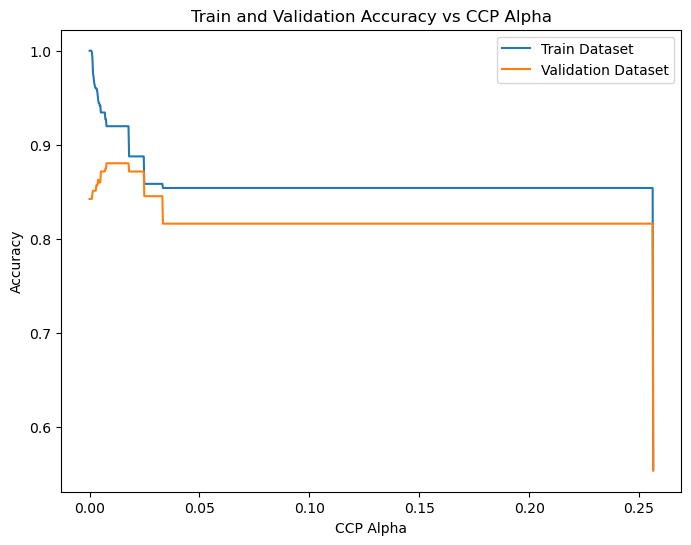

In [8]:
best_ccp_alpha = max(val_accuracies, key=val_accuracies.get)
print(f"Best ccp alpha value: {best_ccp_alpha:.6f}: validation accuracy {val_accuracies[best_ccp_alpha]:.6f}, train accuracy {train_accuracies[best_ccp_alpha]:.4f}")
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(list(train_accuracies.keys()), list(train_accuracies.values()), label='Train Dataset')
ax.plot(list(val_accuracies.keys()), list(val_accuracies.values()), label='Validation Dataset')
ax.set_xlabel('CCP Alpha')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_title('Train and Validation Accuracy vs CCP Alpha')
plt.show()

In [9]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

def plot_class_tree_sklearn(tree):
    tree.fit(X, Y)
    
    dot_data = export_graphviz(tree,
                               feature_names=['variance', 'entropy'],
                              class_names = ["Genuine","Forged"],out_file=None)  
    
    graph = graphviz.Source(dot_data) 
    
    return graph

Test set accuracy: 0.8688046647230321


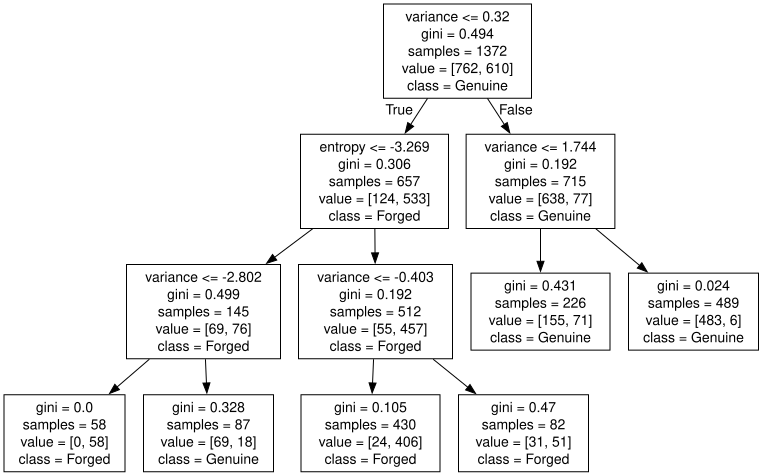

In [10]:
clf = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
clf.fit(X_train, Y_train)
print(f"Test set accuracy: {clf.score(X_test, Y_test)}")

plot_class_tree_sklearn(clf)